### Importing and Cleaning Data

In [106]:
library(ggthemes)
library(magrittr) 
library(rvest)
library(dplyr)
library(tidyverse)
library(tidyr)
library(ggplot2)
library(lubridate)

# Creating the table with data from the csv file
data <- read.table('data_2.csv', header = TRUE,  sep = ',',  stringsAsFactors = FALSE)

# Checking for missing values in the data frame: there are none
sum(is.na(data))

[1] 0

### Determing the maximum and second maximum pixel values 

For each plane I create a separate data frame, with column names reffering to the pixel indices

In [107]:
# Upstream Matrix
px_data_1 <- data[,1:64]
colnames(px_data_1) <- as.character(0:63)

# Downstream Matrix
px_data_2 <- data[,65:128]
colnames(px_data_2) <- as.character(0:63)

Getting the maximum and 2nd maximum pixel values

In [108]:
# Maximum
max_px_value_1 <- apply(px_data_1, 1, max)
max_px_value_2 <- apply(px_data_2, 1, max)

max_px_value_1
max_px_value_2

# Second Maximum

snd_max_1 <- apply(px_data_1, 1, function(x) sort(x, decreasing = TRUE)[2])
snd_max_2 <- apply(px_data_2, 1, function(x) sort(x, decreasing = TRUE)[2])

snd_max_1
snd_max_2

[1]  2.63879e+04  6.21000e+00  2.90721e+03  2.02650e+02  3.29752e+04
     [6]  6.01500e+01  1.59792e+04  5.88000e+01  1.99302e+04  1.39600e+01
    [11]  3.86620e+02  9.70210e+02  3.81500e+01  3.26200e+01  1.47721e+03
    [16]  2.62100e+01  6.82221e+03  5.01710e+02  3.32150e+02  1.82472e+04
    [21]  9.83210e+02  2.39421e+03  2.16221e+03  3.29752e+04  1.04900e+01
    [26]  9.45620e+02  8.78890e+02  4.57221e+03  1.20610e+02  1.11062e+03
    [31]  3.29752e+04  2.75521e+03  1.08900e+01  3.29752e+04  1.37321e+03
    [36]  1.39800e+01  8.91000e+00  6.18715e+03  3.92100e+01  3.29752e+04
    [41]  9.79999e+00  7.64999e+00  4.89999e+00  7.13000e+00  9.96000e+00
    [46]  7.49000e+00  7.88000e+00  1.42000e+00  6.50000e+00  7.61000e+00
    [51]  1.55500e+01  6.42000e+00  5.22000e+00  1.30005e-01  4.96000e+00
    [56]  6.71001e+00  9.54999e+00  6.71001e+00  5.98001e+00  2.22000e+00
    [61]  5.06000e+00  1.19600e+01  1.37100e+01  2.01000e+00  4.06000e+00
    [66]  8.95999e+00  8.96000e+00  1.49300e+01  7.64999e+00  1.07000e+00
    [71]  2.90000e+00  9.71001e+00  1.35500e+01  3.36000e+00  5.62000e+00
    [76]  4.31500e+01  1.29312e+04  6.32200e+01  7.29021e+03  9.01500e+01
    [81]  1.69300e+01  4.26200e+01  9.21001e+00  3.25889e+04  1.00620e+02
    [86]  1.07620e+02  1.06310e+02  3.66200e+01  1.32910e+02  4.26200e+01
    [91]  1.01210e+02  5.22100e+01  3.26286e+04  3.08620e+02  1.12962e+03
    [96]  5.11500e+01  3.23932e+04  3.27552e+04  9.26150e+02  1.59600e+01
   [101]  4.31500e+01  7.11515e+03  4.92100e+01  3.26921e+03  4.72100e+01
   [106]  3.92100e+01  2.52300e+01  4.21715e+03  1.71662e+04  1.57100e+01
   [111]  4.71500e+01  3.29752e+04  7.61421e+03  3.52100e+01  1.00610e+02
   [116]  4.10400e+01  9.93000e+00  1.02100e+01  9.26200e+01  5.02100e+01
   [121]  1.23150e+02  9.71500e+01  3.49393e+03  3.22100e+01  3.25889e+04
   [126]  9.29001e+00  3.47620e+02  3.46620e+02  7.80000e+00  3.04415e+03
   [131]  3.26286e+04  6.92100e+01  5.71500e+01  3.26286e+04  1.22712e+04
   [136]  6.92123e+03  4.92100e+01  3.42100e+01  1.30620e+02  3.61500e+01
   [141]  7.03262e+03  5.68900e+01  1.03200e+01  4.12461e+03  1.16210e+02
   [146]  4.22100e+01  3.36200e+01  2.61550e+02  9.12900e+01  1.08021e+03
   [151]  7.72100e+01  1.09550e+02  4.82100e+01  4.72100e+01  1.42100e+01
   [156]  3.02100e+01  5.04210e+02  2.84210e+02  1.80922e+04  4.59150e+02
   [161]  3.23932e+04  3.46200e+01  3.29752e+04  7.85150e+02  1.11230e+02
   [166]  2.39230e+02  9.42000e+00  3.27552e+04  9.82300e+01  3.26286e+04
   [171]  1.28470e+02  3.61500e+01  3.26286e+04  9.62000e+00  4.01500e+01
   [176]  1.09230e+02  4.54989e+03  3.31500e+01  1.09712e+04  3.32100e+01
   [181]  7.76562e+03  3.99821e+03  3.29752e+04  5.12100e+01  7.62100e+01
   [186]  5.22100e+01  3.12100e+01  1.46521e+03  3.02100e+01  1.32896e+04
   [191]  2.85716e+04  8.98001e+00  4.98001e+00  1.19300e+01  4.18900e+01
   [196]  1.08000e+01  8.92100e+01  3.26286e+04  1.22300e+01  1.76100e+01
   [201]  3.69215e+03  1.92462e+04  2.02152e+04  3.29752e+04  5.71620e+02
   [206]  2.39215e+03  2.36100e+01  3.26286e+04  3.26286e+04  3.21001e+00
   [211]  3.66200e+01  3.26286e+04  3.27552e+04  9.03150e+02  5.58223e+03
   [216]  5.49000e+00  1.27100e+01  1.69600e+01  3.27552e+04  3.76200e+01
   [221]  3.28865e+03  4.40400e+01  9.21000e+00  1.47421e+03  7.15621e+03
   [226]  5.02100e+01  1.42421e+03  8.89000e+00  1.85210e+02  3.49210e+02
   [231]  4.05015e+03  3.23932e+04  2.27515e+03  4.76200e+01  3.29752e+04
   [236]  3.26286e+04  3.27552e+04  4.22610e+02  4.61100e+01  1.39620e+02
   [241]  3.23932e+04  2.63382e+04  9.21000e+00  4.43721e+03  2.84070e+03
   [246]  4.21001e+00  2.62100e+01  2.13610e+02  1.00721e+03  6.76210e+02
   [251]  7.80000e+00  2.75150e+02  3.96200e+01  5.58230e+02  4.41700e+01
   [256]  3.17615e+03  1.40762e+04  3.95500e+01  3.27552e+04  2.22100e+01
   [261]  3.27552e+04  1.34900e+01  1.03620e+02  1.58800e+01  3.86200e+01
   [266]  3.16210e+02  8.88989e+03  4.82100e+01  7.97562e+03  1.89360e+02
   [271] 

[1] 2.46633e+04 1.25200e+01 3.53723e+03 1.04680e+02 3.27582e+04 3.45300e+01
     [7] 1.97912e+04 6.35800e+01 2.40862e+04 1.69700e+01 3.72960e+02 1.11123e+03
    [13] 4.85300e+01 5.69600e+01 1.59123e+03 4.62300e+01 7.23423e+03 5.38900e+02
    [19] 3.07530e+02 1.71965e+04 1.35023e+03 2.60323e+03 2.22752e+03 3.27582e+04
    [25] 1.85700e+01 8.59960e+02 7.57340e+02 4.84752e+03 1.08570e+02 1.20996e+03
    [31] 3.27582e+04 1.06323e+03 1.26800e+01 3.27582e+04 1.43123e+03 1.32200e+01
    [37] 1.29600e+01 5.86053e+03 7.12300e+01 3.27582e+04 5.39999e+00 8.39999e+00
    [43] 4.22000e+00 2.67999e+00 8.97000e+00 6.86000e+00 6.16000e+00 7.88000e+00
    [49] 1.07700e+01 5.26001e+00 1.89700e+01 8.55000e+00 7.32001e+00 1.22200e+01
    [55] 8.31000e+00 7.39999e+00 1.09700e+01 1.01600e+01 7.87000e+00 1.03200e+01
    [61] 4.67999e+00 1.20500e+01 1.29700e+01 7.86000e+00 2.47000e+00 6.58000e+00
    [67] 2.97000e+00 1.19700e+01 6.67999e+00 4.23999e+00 1.16700e+01 5.89999e+00
    [73] 9.86000e+00 6.94000e+00 4.16000e+00 1.62220e+02 1.41204e+04 6.44600e+01
    [79] 1.32622e+04 7.25300e+01 1.02300e+01 4.59600e+01 9.23000e+00 3.29723e+04
    [85] 1.64960e+02 1.06960e+02 4.25200e+01 3.59600e+01 5.84100e+01 4.79600e+01
    [91] 1.00520e+02 1.07230e+02 3.29070e+04 3.07960e+02 1.26896e+03 4.15300e+01
    [97] 3.30665e+04 3.27505e+04 6.52530e+02 2.19700e+01 4.15300e+01 6.58753e+03
   [103] 4.05200e+01 6.77023e+03 4.45200e+01 4.05200e+01 1.52400e+01 4.11553e+03
   [109] 1.49725e+04 1.69700e+01 4.25300e+01 7.68123e+03 1.27712e+04 5.32300e+01
   [115] 9.05700e+01 2.29000e+01 1.39700e+01 1.19700e+01 3.79600e+01 4.42300e+01
   [121] 1.22530e+02 3.45300e+01 7.10983e+03 4.55200e+01 3.29723e+04 1.26200e+01
   [127] 4.19960e+02 1.35496e+03 2.45200e+01 2.95053e+03 3.29070e+04 1.09230e+02
   [133] 3.85300e+01 3.29070e+04 1.10255e+04 6.63252e+03 4.82300e+01 5.12300e+01
   [139] 1.08960e+02 4.75300e+01 7.47796e+03 5.13400e+01 7.23000e+00 3.81157e+03
   [145] 2.75470e+02 6.92300e+01 4.49600e+01 2.72510e+02 1.77940e+02 1.40023e+03
   [151] 1.12230e+02 1.21160e+02 4.62300e+01 3.75200e+01 1.13300e+01 7.05200e+01
   [157] 6.62230e+02 2.13604e+03 2.07025e+04 5.48520e+02 3.30665e+04 4.29600e+01
   [163] 3.27582e+04 6.72530e+02 1.18410e+02 6.91570e+02 7.26001e+00 3.27505e+04
   [169] 9.84100e+01 3.29070e+04 9.94300e+01 3.35300e+01 3.29070e+04 8.96001e+00
   [175] 4.75300e+01 8.44100e+01 4.54134e+03 4.15300e+01 1.25505e+04 5.02300e+01
   [181] 9.80796e+03 5.36623e+03 3.27582e+04 4.12300e+01 8.85200e+01 3.95200e+01
   [187] 3.82300e+01 1.36852e+03 3.62300e+01 1.63590e+04 3.29070e+04 2.95999e+00
   [193] 5.32001e+00 1.09700e+01 1.33400e+01 1.02300e+01 1.09520e+02 3.29070e+04
   [199] 1.24100e+01 3.75700e+01 3.49553e+03 1.89085e+04 3.01372e+04 3.29070e+04
   [205] 6.56960e+02 2.34853e+03 3.35700e+01 3.29070e+04 3.29070e+04 8.23000e+00
   [211] 3.89600e+01 3.29070e+04 3.27505e+04 8.88530e+02 5.81741e+03 4.37000e+00
   [217] 1.18600e+01 9.29001e+00 3.27505e+04 3.29600e+01 3.22168e+03 6.49600e+01
   [223] 8.17999e+00 2.53923e+03 7.88252e+03 3.72300e+01 1.03935e+04 1.43400e+01
   [229] 1.94230e+02 2.99520e+02 7.31123e+03 3.30665e+04 1.95553e+03 5.79600e+01
   [235] 2.20352e+04 3.29070e+04 3.27505e+04 1.56752e+03 5.80600e+01 8.89600e+01
   [241] 2.00845e+04 2.94365e+04 1.33100e+01 4.44352e+03 1.32596e+03 5.23000e+00
   [247] 1.83200e+01 1.92570e+02 1.14252e+03 7.49520e+02 7.23000e+00 2.88530e+02
   [253] 3.79600e+01 5.71410e+02 4.62000e+01 2.18153e+03 1.10095e+04 5.85500e+01
   [259] 3.27505e+04 1.55200e+01 3.27505e+04 7.22000e+00 1.10960e+02 1.21300e+01
   [265] 4.19600e+01 7.82520e+02 6.55934e+03 3.25200e+01 7.45496e+03 1.44290e+02
   [271] 1.23400e+01 5.33400e+01 2.75662e+04 3.29723e+04 3.75200e+01 7.23300e+01
   [277] 2.77700e+01 1.69600e+01 5.94600e+01 9.11600e+01 2.17570e+02 6.12300e+01
   [283] 7.64960e+02 3.25200e+01 2.09700e+01 1.39000e+01 4.63400e+01 9.12300e+01
   [289] 8.76410e+02 7.29196e+03 3.75200e+01 1.34340e+02 2.12960e+02 6.24700e+01
   [295] 8.23000e+00 2.76934e+03 9.6

[1]  3.69704e+03  3.80000e+00  5.57040e+02  9.71001e+00  2.26560e+04
     [6]  7.89000e+00  1.93104e+03  5.72200e+01  2.25661e+03  1.20100e+01
    [11]  9.20400e+01  1.92040e+02  1.57100e+01  3.20100e+01  5.65610e+02
    [16]  1.07100e+01  9.86610e+02  3.86610e+02  4.52900e+01  1.30423e+03
    [21]  5.44010e+02  3.92040e+02  5.78610e+02  1.60500e+04  9.88000e+00
    [26]  2.84040e+02  1.90650e+02  1.33061e+03  9.93000e+00  2.73040e+02
    [31]  1.05090e+04  7.47740e+02  1.03600e+01  5.10504e+03  2.33610e+02
    [36]  1.29800e+01  5.96000e+00  7.85290e+02  9.03999e+00  2.78904e+03
    [41]  7.95001e+00  7.21001e+00  2.98000e+00  6.70000e+00  8.71001e+00
    [46]  5.93000e+00  7.50999e+00  9.60007e-01  5.85000e+00  7.01000e+00
    [51]  1.29600e+01  6.36000e+00  4.89000e+00 -1.60004e-01  2.80000e+00
    [56]  5.96000e+00  8.88000e+00  5.22000e+00  3.82000e+00  1.22000e+00
    [61]  5.03999e+00  9.93000e+00  1.12900e+01  1.91000e+00  3.80000e+00
    [66]  8.22000e+00  8.71001e+00  7.96000e+00  5.89000e+00  8.50000e-01
    [71]  9.30000e-01  8.22000e+00  1.27100e+01  2.01000e+00  3.98001e+00
    [76]  4.18200e+01  1.61529e+03  5.79000e+01  1.18061e+03  2.27100e+01
    [81]  1.59600e+01  1.20400e+01  4.61000e+00  1.47812e+04  1.90400e+01
    [86]  7.00400e+01  5.12100e+01  1.04900e+01  4.02300e+01  1.60400e+01
    [91]  3.32900e+01  3.72100e+01  2.23082e+04  6.90400e+01  2.60040e+02
    [96]  1.57100e+01  1.97887e+04  3.35261e+03  1.41890e+02  1.57100e+01
   [101]  1.52900e+01  7.75890e+02  2.06100e+01  7.43610e+02  1.29800e+01
   [106]  3.06100e+01  9.71001e+00  5.15290e+02  1.08289e+03  1.39300e+01
   [111]  1.56500e+01  2.31300e+04  1.23861e+03  3.71001e+00  8.71001e+00
   [116]  1.09800e+01  9.62000e+00  5.96000e+00  2.70400e+01  1.72100e+01
   [121]  1.16210e+02  1.52900e+01  6.80150e+02  6.96000e+00  1.39723e+03
   [126]  8.47000e+00  9.12100e+01  3.03550e+02  6.95999e+00  3.62890e+02
   [131]  1.50982e+04  9.42000e+00  1.42900e+01  7.93221e+03  9.95890e+02
   [136]  2.77221e+03  1.76100e+01  9.01000e+00  3.30400e+01  8.22000e+00
   [141]  1.29104e+03  2.95100e+01  9.96001e+00  6.09300e+01  3.47000e+01
   [146]  2.01500e+01  4.84000e+00  2.54320e+02  7.53200e+01  3.29910e+02
   [151]  4.73900e+01  1.00980e+02  2.92100e+01  1.66100e+01  1.29600e+01
   [156]  2.42900e+01  8.66100e+01  1.76220e+02  2.97961e+03  1.15110e+02
   [161]  8.39265e+03  1.50400e+01  2.16000e+04  1.04890e+02  2.62900e+01
   [166]  1.88910e+02  7.96000e+00  1.38229e+04  2.42900e+01  2.18902e+04
   [171]  4.22200e+01  9.22000e+00  1.79112e+04  7.96000e+00  1.69600e+01
   [176]  9.60100e+01  6.02650e+02  6.55000e+00  2.40661e+03  2.46100e+01
   [181]  1.44604e+03  5.77610e+02  2.31260e+04  1.80400e+01  1.36100e+01
   [186]  1.86100e+01  1.60400e+01  3.82610e+02  1.67100e+01  2.01604e+03
   [191]  4.28089e+03  8.62000e+00  3.93000e+00  1.17100e+01  1.49600e+01
   [196]  9.55000e+00  3.26100e+01  2.69804e+03  7.90000e+00  3.82000e+00
   [201]  5.42890e+02  1.26289e+03  1.96104e+03  3.26286e+04  1.22040e+02
   [206]  3.75890e+02  1.42200e+01  6.83221e+03  2.21512e+04  3.99933e-02
   [211]  1.09600e+01  5.01221e+03  1.85529e+04  2.12620e+02  1.15729e+03
   [216]  5.21001e+00  1.19300e+01  1.26100e+01  1.86889e+04  1.50400e+01
   [221]  8.06980e+02  4.36200e+01  4.39000e+00  1.19415e+03  1.66261e+03
   [226]  3.62000e+00  1.17723e+03  2.22000e+00  3.82200e+01  8.46100e+01
   [231]  3.92421e+03  1.28807e+04  4.70890e+02  1.60400e+01  1.65500e+04
   [236]  7.66021e+03  3.88461e+03  3.82100e+01  2.16200e+01  3.80400e+01
   [241]  1.57557e+04  3.11961e+03  7.06000e+00  2.03761e+03  1.10462e+03
   [246]  1.98000e+00  2.42100e+01  1.88620e+02  2.51610e+02  1.74610e+02
   [251]  7.62000e+00  4.68200e+01  8.49000e+00  1.32290e+02  4.23900e+01
   [256]  3.85890e+02  1.09489e+03  3.83100e+01  1.69519e+04  7.23000e+00
   [261]  8.13093e+03  1.04200e+01  2.80400e+01  1.42100e+01  1.26900e+01
   [266]  2.22210e+02  9.53620e+02  2.86100e+01  1.39104e+03  1.46510e+02
   [271] 

[1]  2.20968e+03  2.95000e+00  5.58900e+02  6.67000e+00  2.07299e+04
     [6]  6.67999e+00  1.94096e+03  4.66300e+01  1.97157e+03  1.44000e+01
    [11]  1.02900e+02  2.07900e+02  1.16800e+01  2.70400e+01  5.48570e+02
    [16]  8.57000e+00  9.83900e+02  2.67570e+02  4.01600e+01  1.38541e+03
    [21]  3.59960e+02  3.99900e+02  6.23570e+02  1.63429e+04  1.62900e+01
    [26]  2.27900e+02  2.05900e+02  1.33757e+03  1.49700e+01  3.06900e+02
    [31]  1.40159e+04  1.02346e+03  1.22900e+01  5.56290e+03  2.28900e+02
    [36]  1.29000e+01  9.97000e+00  7.43160e+02  8.89999e+00  3.68290e+03
    [41]  4.32001e+00  7.67999e+00  4.16000e+00  2.58000e+00  7.95999e+00
    [46]  6.16000e+00  5.29001e+00  5.51000e+00  9.32001e+00  4.06000e+00
    [51]  7.39999e+00  6.51999e+00  5.51999e+00  8.03999e+00  7.80000e+00
    [56]  7.29001e+00  8.32001e+00  8.42999e+00  6.94000e+00  9.16000e+00
    [61]  4.53999e+00  1.16300e+01  1.26800e+01  7.67000e+00  2.04000e+00
    [66]  5.04000e+00  2.86000e+00  1.02400e+01  6.23999e+00  3.06000e+00
    [71]  1.06800e+01  5.63000e+00  8.29001e+00  5.97000e+00  2.67999e+00
    [76]  4.05300e+01  1.36116e+03  6.15700e+01  8.28570e+02  1.21600e+01
    [81]  7.86000e+00  1.69700e+01  3.89999e+00  1.64494e+04  2.99000e+01
    [86]  7.59000e+01  8.57000e+00  1.12700e+01  1.21600e+01  1.39000e+01
    [91]  3.05700e+01  9.22000e+00  2.05325e+04  5.89000e+01  2.90900e+02
    [96]  1.06200e+01  2.08627e+04  9.52123e+03  1.85630e+02  1.69000e+01
   [101]  3.14100e+01  8.05340e+02  1.23300e+01  6.65990e+03  2.35700e+01
   [106]  4.04700e+01  1.46700e+01  5.57340e+02  1.25934e+03  1.25200e+01
   [111]  9.16000e+00  1.69752e+03  7.00570e+02  9.37000e+00  9.97000e+00
   [116]  6.51999e+00  8.96001e+00  7.22000e+00  1.29700e+01  1.09000e+01
   [121]  1.07230e+02  8.89999e+00  7.27530e+02  1.65700e+01  1.62696e+03
   [126]  1.15300e+01  9.19000e+01  3.95860e+02  7.97000e+00  3.86340e+02
   [131]  1.71645e+04  1.49000e+01  1.15200e+01  9.27452e+03  1.12534e+03
   [136]  2.61541e+03  9.57000e+00  1.23300e+01  4.79500e+01  1.15200e+01
   [141]  1.20090e+03  2.28800e+01  7.22000e+00  1.16520e+02  7.45200e+01
   [146]  2.75300e+01  2.09000e+01  2.68160e+02  1.27620e+02  2.43040e+02
   [151]  6.86800e+01  1.07290e+02  3.02600e+01  1.68600e+01  1.12300e+01
   [156]  6.29000e+01  8.29000e+01  8.50970e+02  2.66157e+03  4.71530e+02
   [161]  7.33768e+03  2.09700e+01  2.04929e+04  9.23400e+01  3.21600e+01
   [166]  2.45410e+02  6.51999e+00  1.61033e+04  2.81600e+01  2.03145e+04
   [171]  4.04000e+01  1.12400e+01  1.83485e+04  8.20000e+00  1.79700e+01
   [176]  4.95700e+01  6.95680e+02  1.11600e+01  2.51257e+03  1.89000e+01
   [181]  1.41190e+03  5.05570e+02  2.09869e+04  1.25700e+01  2.25700e+01
   [186]  1.48600e+01  6.86000e+00  3.51570e+02  1.69700e+01  2.38190e+03
   [191]  2.17934e+03  2.22000e+00  4.33002e+00  1.02300e+01  6.33002e+00
   [196]  9.95000e+00  3.25700e+01  3.80852e+03  9.33002e+00  4.32001e+00
   [201]  6.74340e+02  1.68134e+03  1.20996e+03  2.04345e+04  1.39900e+02
   [206]  4.50160e+02  1.33100e+01  8.38452e+03  2.04475e+04  8.17999e+00
   [211]  1.32300e+01  5.22852e+03  1.97633e+04  2.79230e+02  1.11016e+03
   [216]  4.23000e+00  1.03200e+01  7.23999e+00  1.84833e+04  6.86000e+00
   [221]  1.06553e+03  4.99000e+01  7.51000e+00  1.12340e+03  1.82857e+03
   [226]  3.95999e+00  2.36657e+03  8.47000e+00  4.93400e+01  7.45700e+01
   [231]  1.34853e+03  1.41437e+04  2.95340e+02  1.89000e+01  1.14957e+03
   [236]  1.03695e+04  3.73857e+03  1.41823e+03  4.19700e+01  2.59000e+01
   [241]  2.40434e+03  2.96757e+03  1.22200e+01  1.91757e+03  8.67470e+02
   [246]  4.29993e-01  9.23000e+00  1.72530e+02  2.97570e+02  1.98570e+02
   [251]  5.97000e+00  4.23400e+01  1.06800e+01  1.30160e+02  4.50400e+01
   [256]  3.18160e+02  1.41323e+03  2.53700e+01  1.75563e+04  9.22000e+00
   [261]  1.04163e+04  6.96001e+00  3.59000e+01  1.18600e+01  2.19700e+01
   [266]  7.25570e+02  2.71996e+03  1.45700e+01  1.26490e+03  1.42430e+02
   [271] 

### Identifying the corresponding pixel indices.

Identifying the corresponding pixel indices to the maximum value

In [109]:
# For the Upstream Matrix
max_index_1 <- apply(px_data_1, 1, function(x) {
  ord <- order(x, decreasing = TRUE)
  list(
    max = x[ord[1]],
    pixel_index = names(x)[ord[1]]
  )
})

#Creating for it a data frame 
max_df_1 <- do.call(rbind, lapply(max_index_1, as.data.frame))
rownames(max_df_1) <- rownames(px_data_1)

# For the Downstream Matrix
max_index_2 <- apply(px_data_2, 1, function(x) {
  ord <- order(x, decreasing = TRUE)
  list(
    max = x[ord[1]],
    pixel_index = names(x)[ord[1]]
  )
})

#Creating for it a data frame 
max_df_2 <- do.call(rbind, lapply(max_index_2, as.data.frame))
rownames(max_df_1) <- rownames(px_data_2)

max_df_1
max_df_2


,max,pixel_index
,<dbl>,<chr>
1,26387.90,43
2,6.21,28
3,2907.21,36
4,202.65,51
5,32975.20,36
6,60.15,35
7,15979.20,36
8,58.80,9
9,19930.20,36


,max,pixel_index
,<dbl>,<chr>
43,24663.30,43
28,12.52,28
36,3537.23,36
51,104.68,51
361,32758.20,36
35,34.53,35
362,19791.20,36
39,63.58,39
363,24086.20,36


Identifying the corresponding pixel indices to the second maximum value

In [110]:
# For the Upstream Matrix
snd_max_index_1 <- apply(px_data_1, 1, function(x) {
  ord <- order(x, decreasing = TRUE)
  list(
    max = x[ord[2]],
    pixel_index = names(x)[ord[2]]
  )
})

#Creating for it a data frame 
snd_max_df_1 <- do.call(rbind, lapply(snd_max_index_1, as.data.frame))
rownames(snd_max_df_1) <- rownames(px_data_1)

# For the Downstream Matrix
snd_max_index_2 <- apply(px_data_2, 1, function(x) {
  ord <- order(x, decreasing = TRUE)
  list(
    max = x[ord[2]],
    pixel_index = names(x)[ord[2]]
  )
})

#Creating for it a data frame 
snd_max_df_2 <- do.call(rbind, lapply(snd_max_index_2, as.data.frame))
rownames(snd_max_df_1) <- rownames(px_data_2)

snd_max_df_1
snd_max_df_2


,max,pixel_index
,<dbl>,<chr>
1,3697.04000,52
2,3.80000,9
3,557.04000,52
4,9.71001,3
5,22656.00000,52
6,7.89000,43
7,1931.04000,52
8,57.22000,50
9,2256.61000,20


,max,pixel_index
,<dbl>,<chr>
51,2209.68000,51
46,2.95000,46
52,558.90000,52
40,6.67000,40
521,20729.90000,52
2,6.67999,2
44,1940.96000,44
50,46.63000,50
20,1971.57000,20


### Plotting the distributions of the indices corresponding to the maximum and second maximum pixel values.

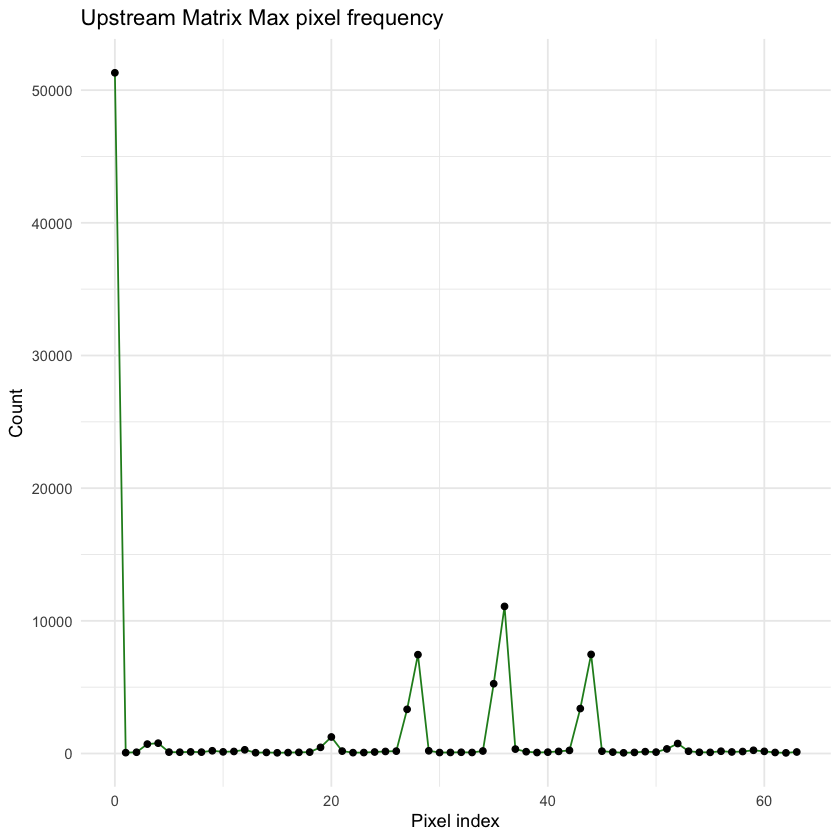

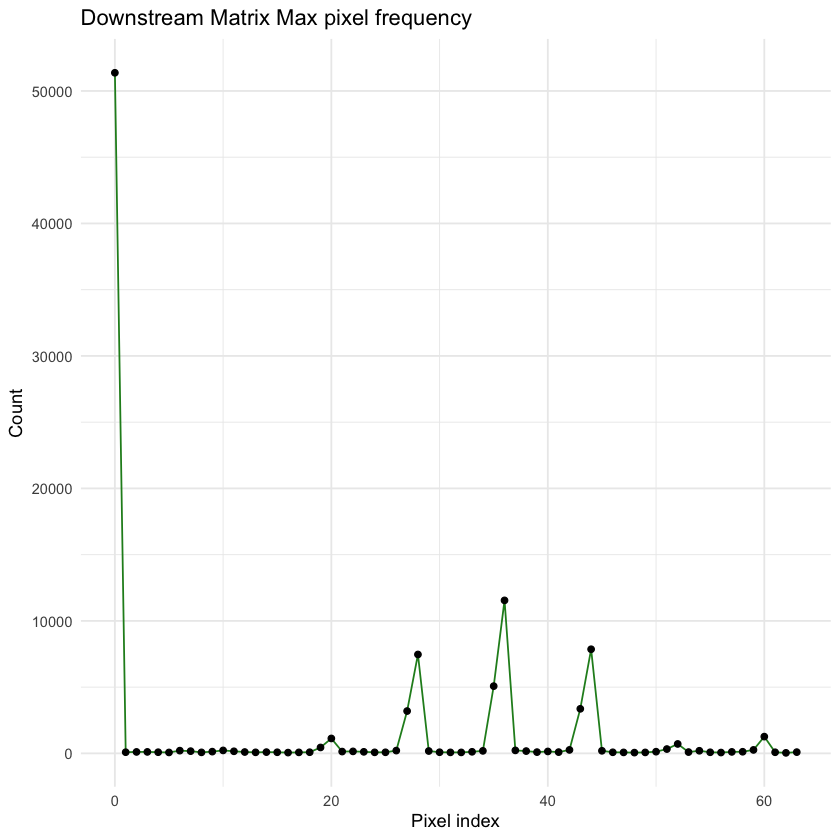

In [111]:
# For the Upstream Matrix

#Creating the groupped data
grp_max_1 <- max_df_1 %>%
  group_by(pixel_index) %>%
  count()

# Plotting the distribution
ggplot(grp_max_1, aes(x = as.numeric(pixel_index), y = n)) +
  geom_line(color = "forestgreen") +
  geom_point() +
  theme_minimal() +
  labs(x = "Pixel index", y = "Count", title = "Upstream Matrix Max pixel frequency") 
  

# For the Downstream Matrix

#Creating the groupped data
grp_max_2 <- max_df_2 %>%
  group_by(pixel_index) %>%
  count()

# Plotting the distribution
ggplot(grp_max_2, aes(x = as.numeric(pixel_index), y = n)) +
  geom_line(color = "forestgreen") +
  geom_point() +
  theme_minimal() +
  labs(x = "Pixel index", y = "Count", title = "Downstream Matrix Max pixel frequency") 



#### Plotting the second maximum pixel frequency

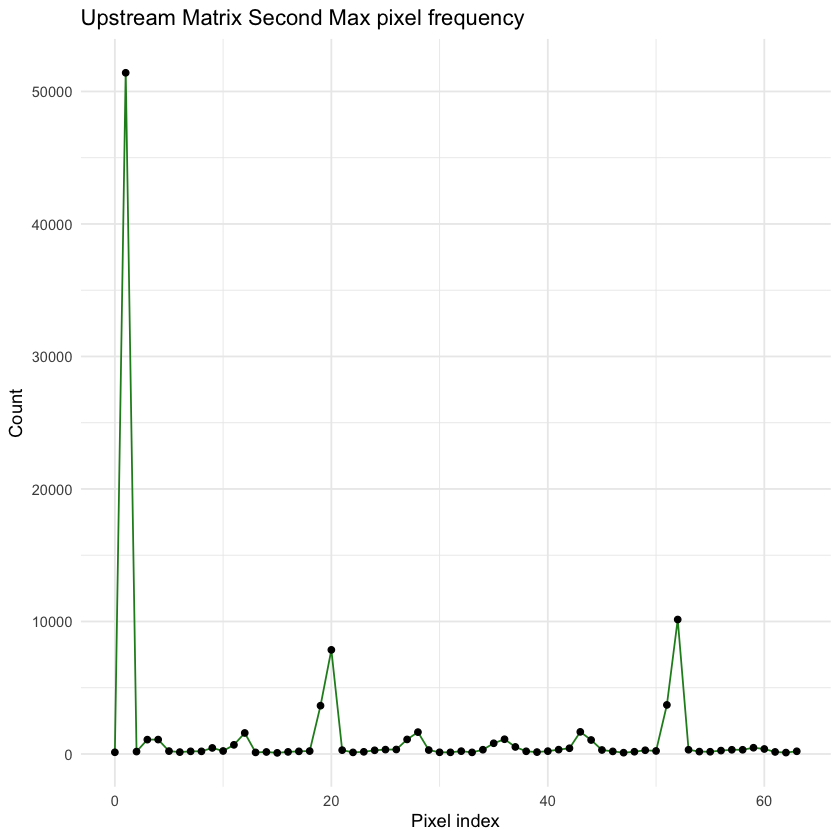

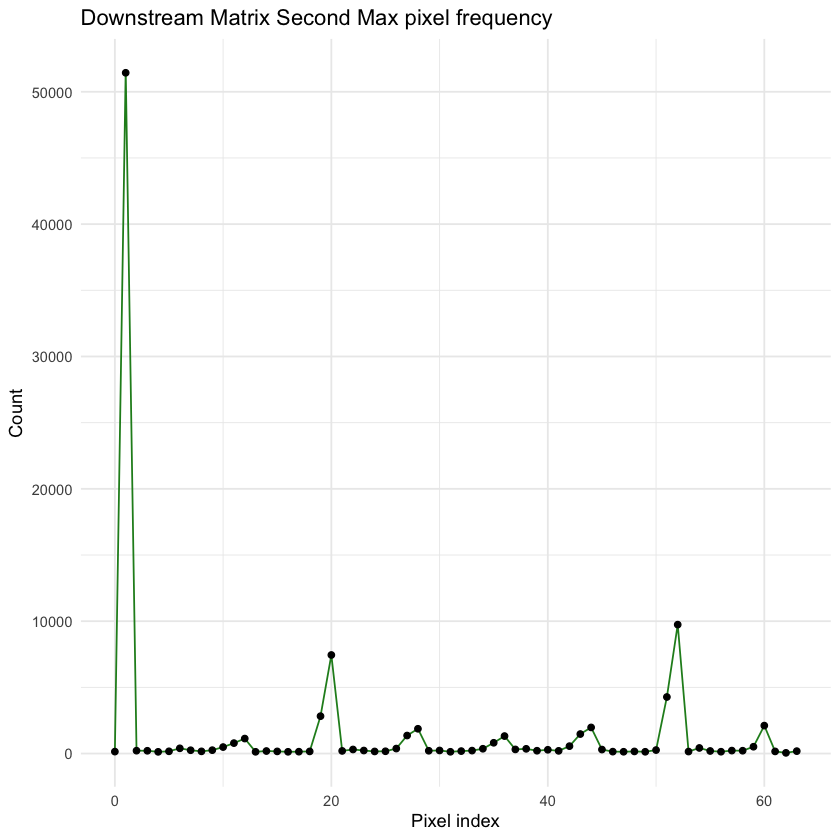

In [112]:
# For the Upstream Matrix

#Creating the groupped data
grp_snd_max_1 <- snd_max_df_1 %>%
  group_by(pixel_index) %>%
  count()

# Plotting the distribution
ggplot(grp_snd_max_1, aes(x = as.numeric(pixel_index), y = n)) +
  geom_line(color = "forestgreen") +
  geom_point() +
  theme_minimal() +
  labs(x = "Pixel index", y = "Count", title = "Upstream Matrix Second Max pixel frequency") 
  

# For the Downstream Matrix

#Creating the groupped data
grp_snd_max_2 <- snd_max_df_2 %>%
  group_by(pixel_index) %>%
  count()

# Plotting the distribution
ggplot(grp_snd_max_2, aes(x = as.numeric(pixel_index), y = n)) +
  geom_line(color = "forestgreen") +
  geom_point() +
  theme_minimal() +
  labs(x = "Pixel index", y = "Count", title = "Downstream Matrix Second Max pixel frequency") 



### Repeatting the same plot but excluding events where the maximum signal is less than 10.

For the Maximum value:

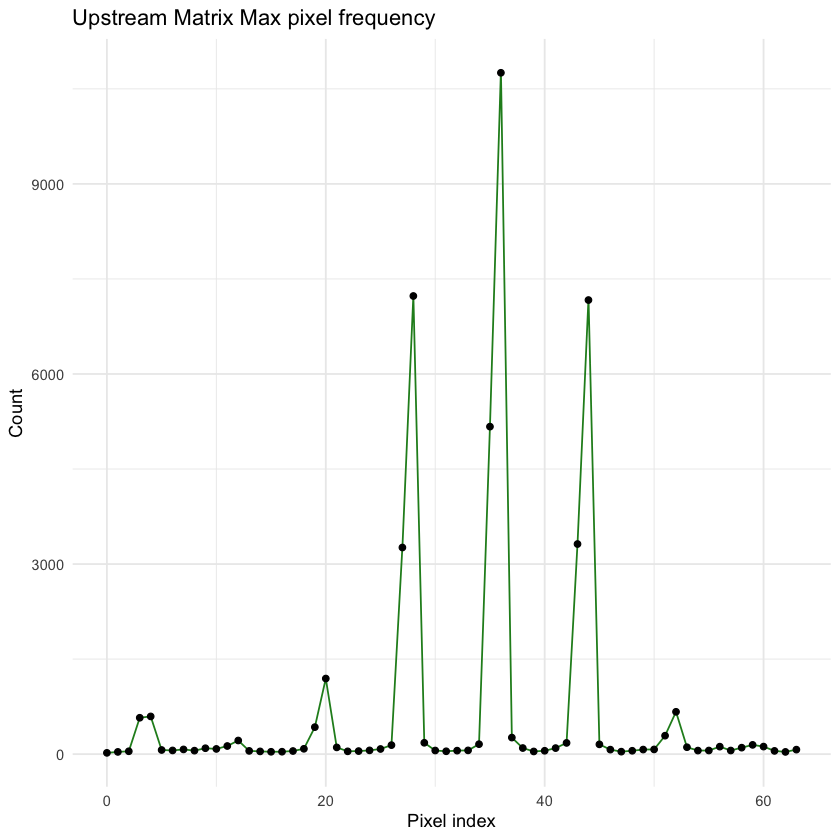

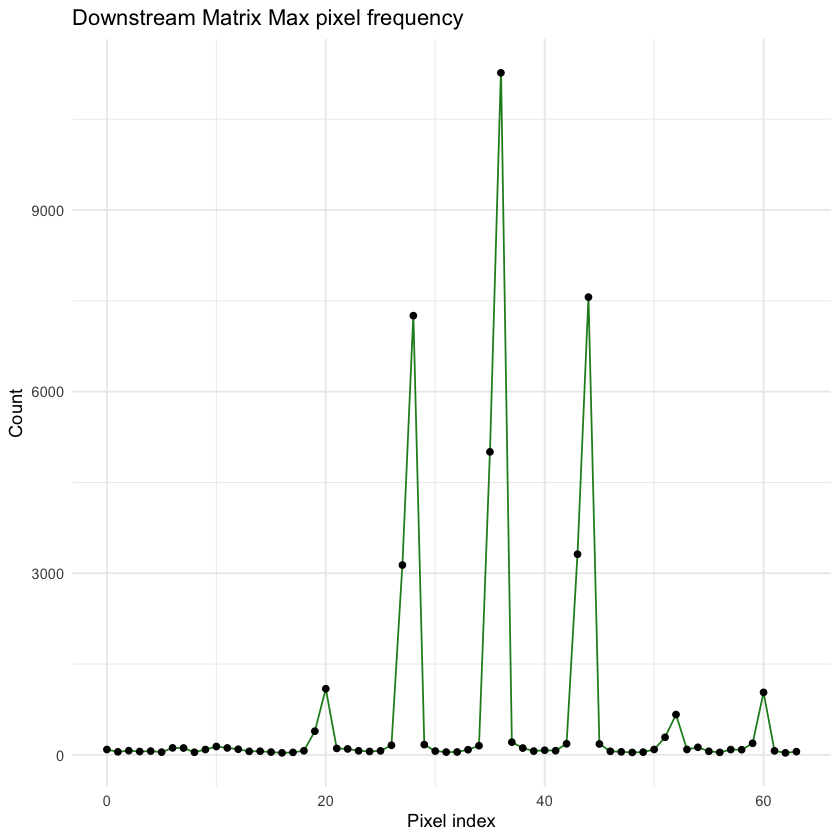

In [113]:
# For the Upstream Matrix

#Creating the groupped data
grp_max_1_r <- max_df_1 %>%
  group_by(pixel_index) %>%
  filter(max > 10) %>%
  count()

# Plotting the distribution
ggplot(grp_max_1_r, aes(x = as.numeric(pixel_index), y = n)) +
  geom_line(color = "forestgreen") +
  geom_point() +
  theme_minimal() +
  labs(x = "Pixel index", y = "Count", title = "Upstream Matrix Max pixel frequency") 
  

# For the Downstream Matrix

#Creating the groupped data
grp_max_2_r <- max_df_2 %>%
  group_by(pixel_index) %>%
  filter(max > 10) %>%
  count()

# Plotting the distribution
ggplot(grp_max_2_r, aes(x = as.numeric(pixel_index), y = n)) +
  geom_line(color = "forestgreen") +
  geom_point() +
  theme_minimal() +
  labs(x = "Pixel index", y = "Count", title = "Downstream Matrix Max pixel frequency") 

For the Second Maximum:

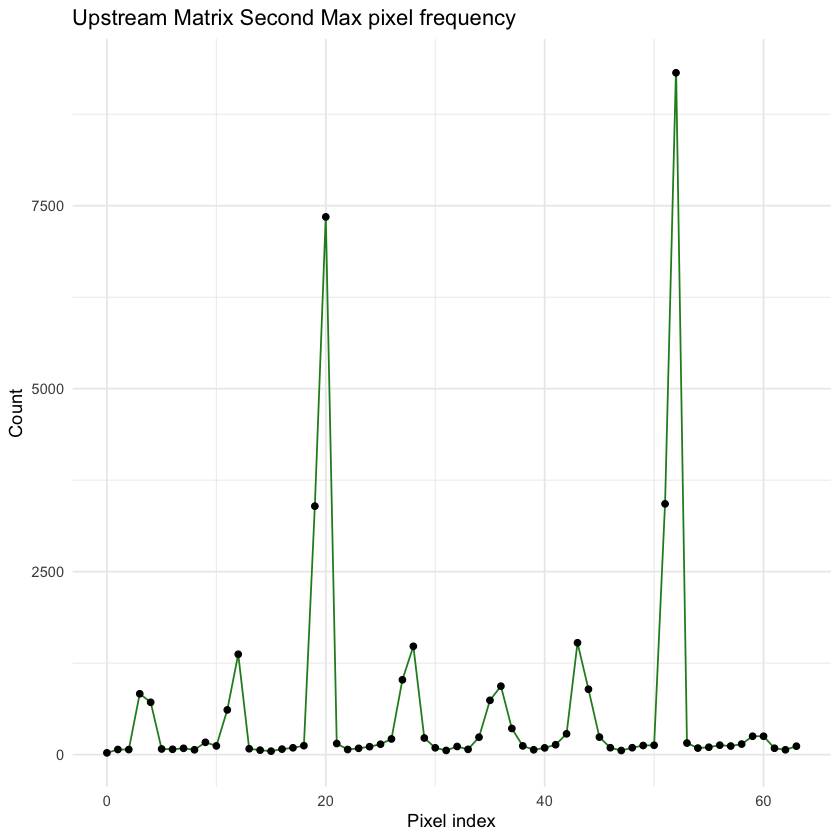

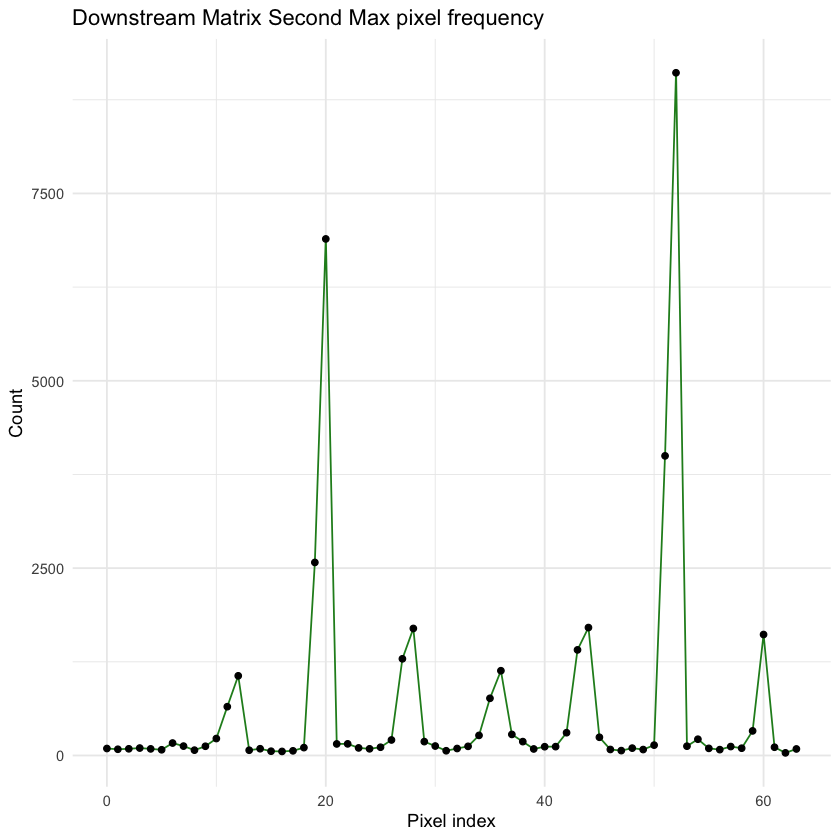

In [114]:
# For the Upstream Matrix

#Creating the groupped data
grp_snd_max_1_r <- snd_max_df_1 %>%
  group_by(pixel_index) %>%
  filter(max > 10) %>%
  count()

# Plotting the distribution
ggplot(grp_snd_max_1_r, aes(x = as.numeric(pixel_index), y = n)) +
  geom_line(color = "forestgreen") +
  geom_point() +
  theme_minimal() +
  labs(x = "Pixel index", y = "Count", title = "Upstream Matrix Second Max pixel frequency") 
  

# For the Downstream Matrix

#Creating the groupped data
grp_snd_max_2_r <- snd_max_df_2 %>%
  group_by(pixel_index) %>%
  filter(max > 10) %>%
  count()

# Plotting the distribution
ggplot(grp_snd_max_2_r, aes(x = as.numeric(pixel_index), y = n)) +
  geom_line(color = "forestgreen") +
  geom_point() +
  theme_minimal() +
  labs(x = "Pixel index", y = "Count", title = "Downstream Matrix Second Max pixel frequency") 



### Computting event-by-event, the ratio between the second and first maximum values.

In [115]:
# For the Upstream Matrix
px_data_ratio_1 <- px_data_1 %>%
    mutate(ratio = max_df_1$max/snd_max_df_1$max,
           row = row_number()) %>%
           select(row, ratio)
         
px_data_ratio_clean_1 <- drop_na(px_data_ratio_1)

# For the Downstream  Matrix
px_data_ratio_2 <- px_data_2 %>%
    mutate(ratio = max_df_2$max/snd_max_df_2$max,
           row = row_number()) %>%
           select(row, ratio)
         
px_data_ratio_clean_2 <- drop_na(px_data_ratio_2)

px_data_ratio_clean_1
px_data_ratio_clean_2

row,ratio
<int>,<dbl>
1,7.137575
2,1.634211
3,5.219033
4,20.870215
5,1.455473
6,7.623574
7,8.274919
8,1.027613
9,8.831920


row,ratio
<int>,<dbl>
1,11.161480
2,4.244068
3,6.328914
4,15.694153
5,1.580239
6,5.169169
7,10.196604
8,1.363500
9,12.216761


### Only consider events where both values are greater than zero. Plot the distribution of this ratio in four different signal ranges:

1. 10 ≤ Max < 300
2. 300 ≤ Max < 1200
3. 1200 ≤ Max < 30000
4. Max ≥ 30000

#### For the Upstream Matrix:

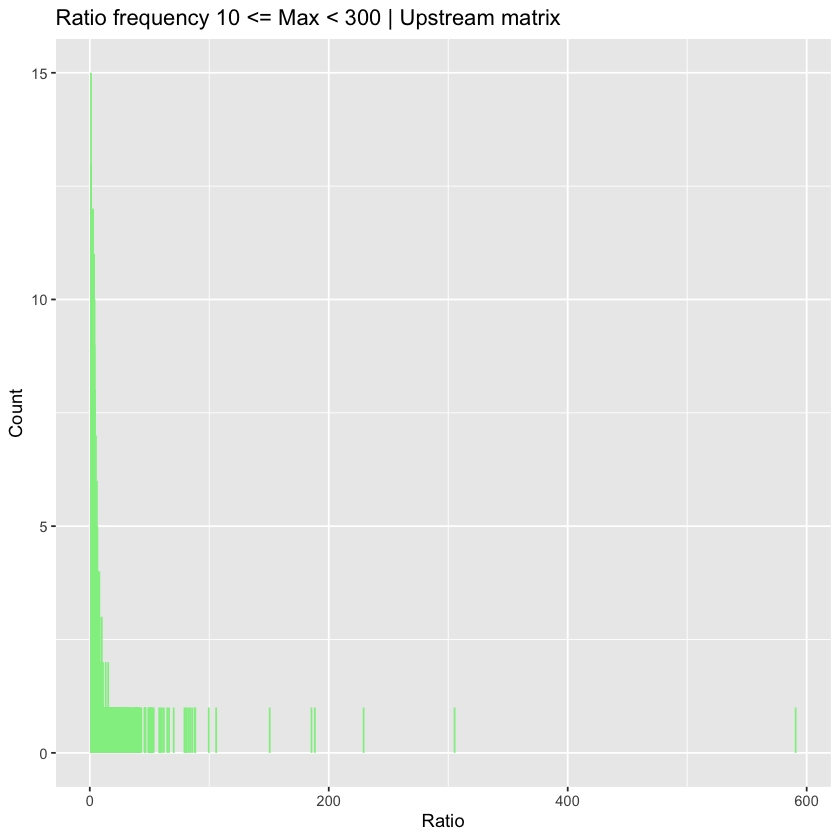

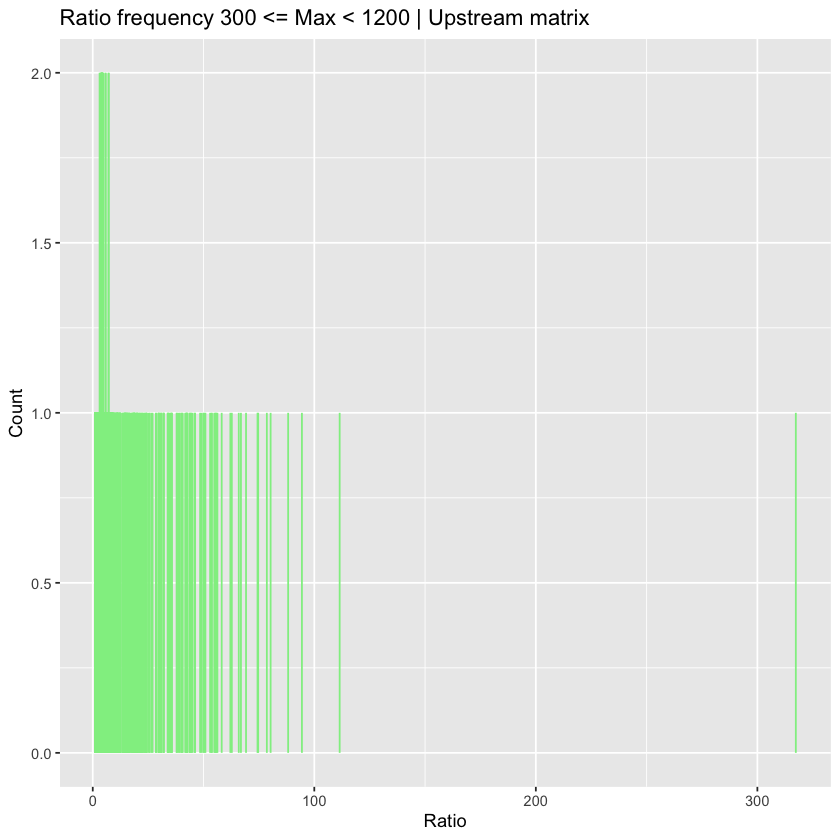

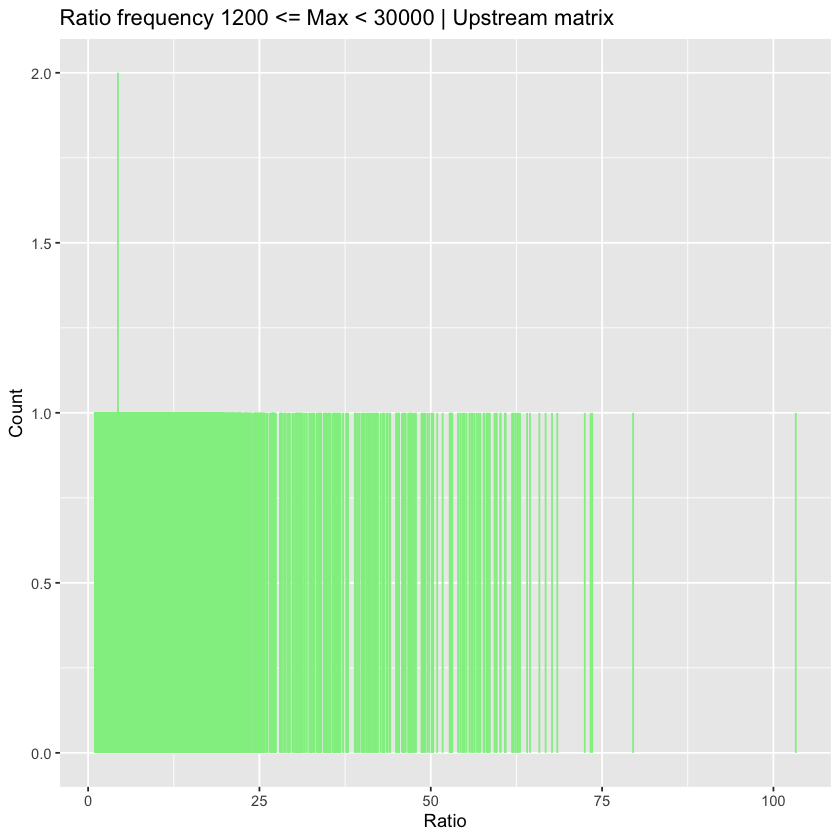

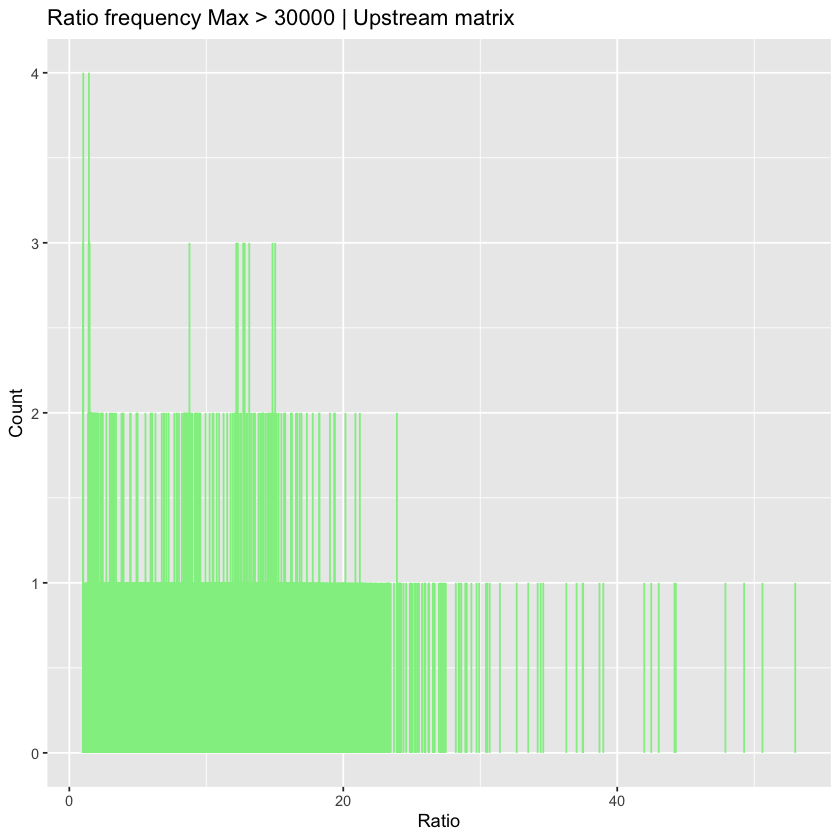

In [116]:
px_data_ratio_plot_1 <- px_data_1 %>%
    mutate(max_px_value = max_df_1$max,
           snd_max_px_value = snd_max_df_1$max,
           ratio = (max_df_1$max/snd_max_df_1$max)) %>%
    filter(snd_max_px_value > 0,
           max_px_value >0)

grp_300 <- px_data_ratio_plot_1 %>%
       group_by(ratio) %>%
       filter(max_px_value >= 10 & max_px_value < 300) %>%
       count()

ggplot(grp_300, aes(x=ratio, y = n)) +
       geom_bar(stat = "identity", color = "lightgreen") +
       labs(x = "Ratio", y = "Count", title = "Ratio frequency 10 <= Max < 300 | Upstream matrix") 

grp_1200 <- px_data_ratio_plot_1 %>%
       group_by(ratio) %>%
       filter(max_px_value >= 300 & max_px_value < 1200) %>%
       count()

ggplot(grp_1200, aes(x=ratio, y = n)) +
       geom_bar(stat = "identity", color = "lightgreen") +
       labs(x = "Ratio", y = "Count", title = "Ratio frequency 300 <= Max < 1200 | Upstream matrix") 

grp_30000 <- px_data_ratio_plot_1 %>%
       group_by(ratio) %>%
       filter(max_px_value >= 1200 & max_px_value < 30000) %>%
       count()

ggplot(grp_30000, aes(x=ratio, y = n)) +
       geom_bar(stat = "identity", color = "lightgreen") +
       labs(x = "Ratio", y = "Count", title = "Ratio frequency 1200 <= Max < 30000 | Upstream matrix") 


grp_30000_plus <- px_data_ratio_plot_1 %>%
       group_by(ratio) %>%
       filter(max_px_value >= 30000 ) %>%
       count()

ggplot(grp_30000_plus, aes(x=ratio, y = n)) +
       geom_bar(stat = "identity", color = "lightgreen") +
       labs(x = "Ratio", y = "Count", title = "Ratio frequency Max > 30000 | Upstream matrix") 

#### For the Downstream Matrix 

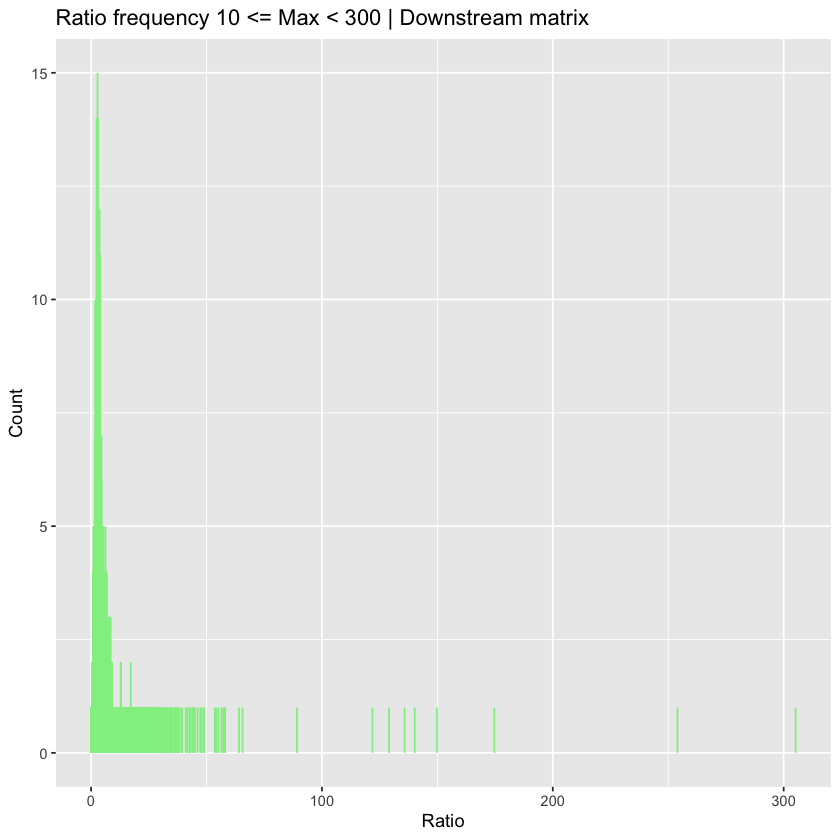

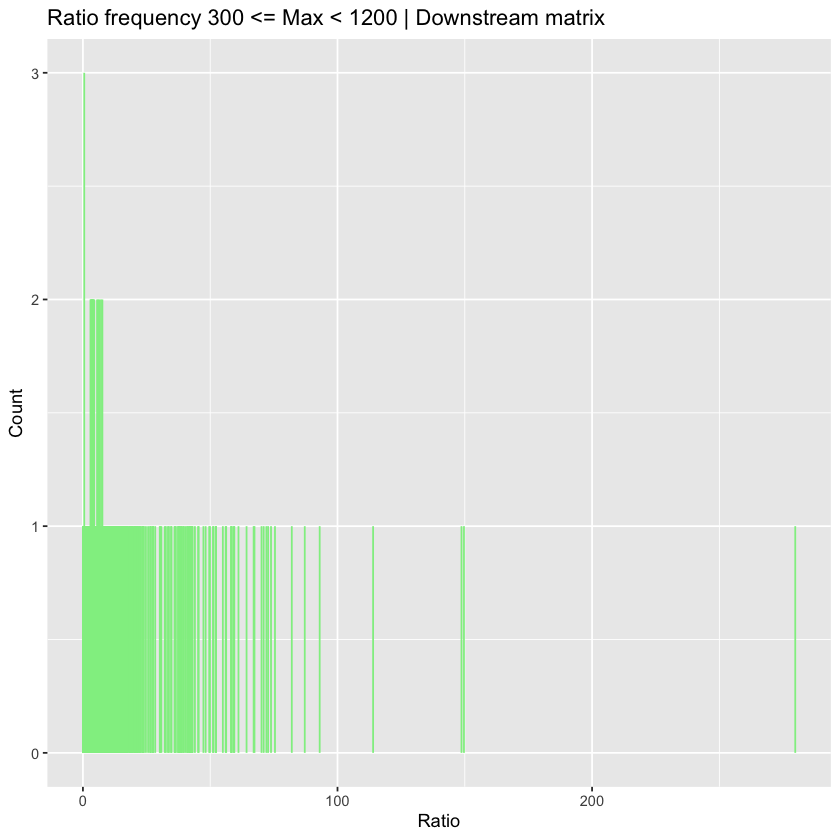

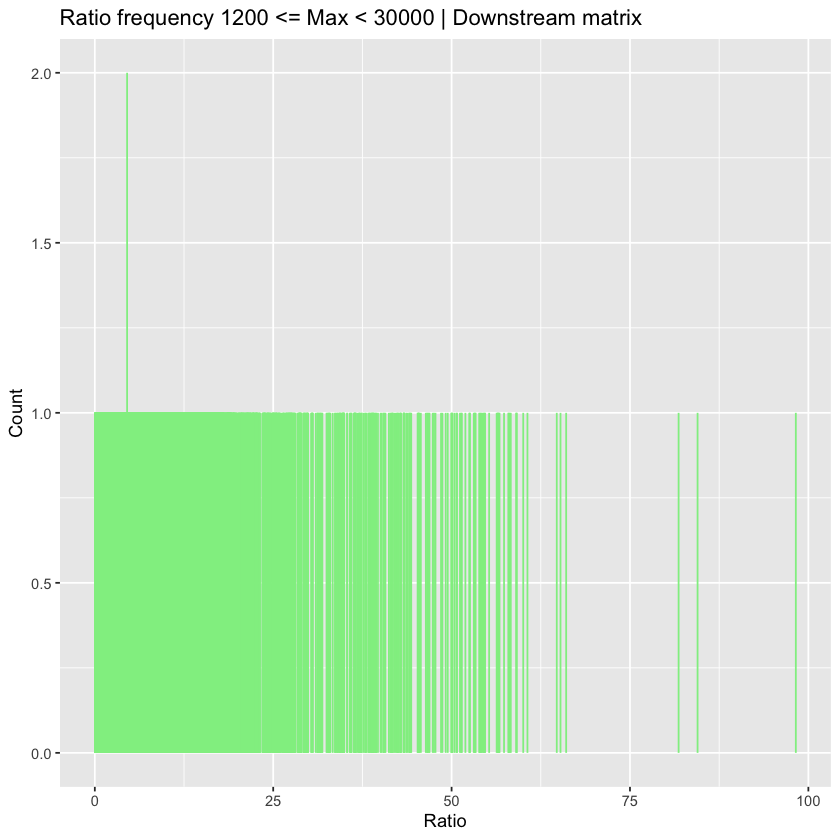

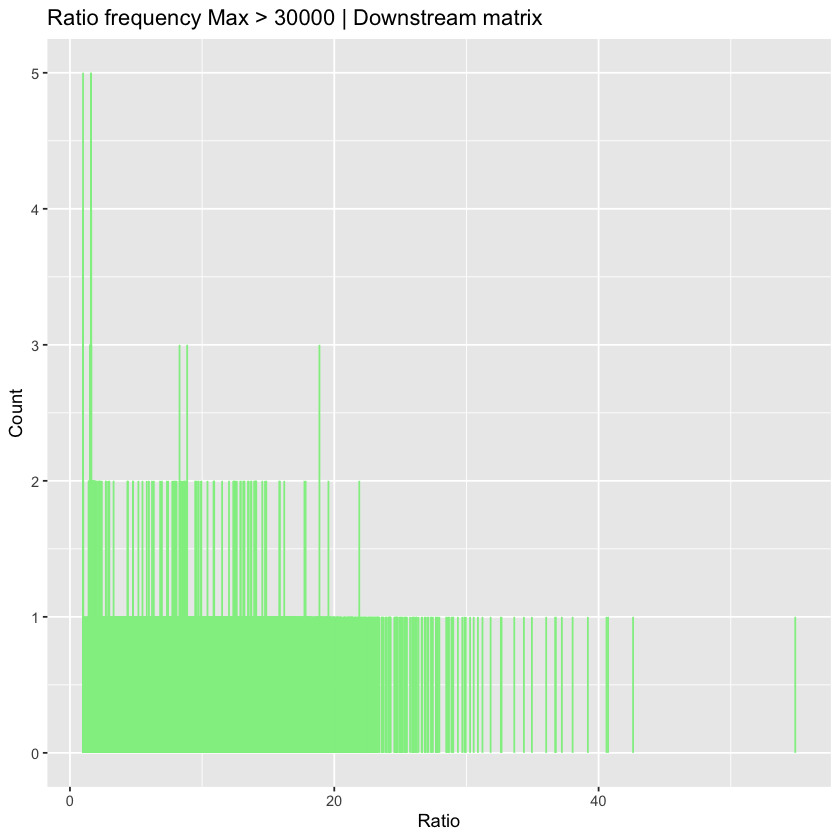

In [117]:
px_data_ratio_plot_2 <- px_data_2 %>%
    mutate(max_px_value = max_df_2$max,
           snd_max_px_value = snd_max_df_2$max,
           ratio = (max_df_1$max/snd_max_df_2$max)) %>%
    filter(snd_max_px_value > 0,
           max_px_value >0)

grp_300 <- px_data_ratio_plot_2 %>%
       group_by(ratio) %>%
       filter(max_px_value >= 10 & max_px_value < 300) %>%
       count()

ggplot(grp_300, aes(x=ratio, y = n)) +
       geom_bar(stat = "identity", color = "lightgreen") +
       labs(x = "Ratio", y = "Count", title = "Ratio frequency 10 <= Max < 300 | Downstream matrix") 

grp_1200 <- px_data_ratio_plot_2 %>%
       group_by(ratio) %>%
       filter(max_px_value >= 300 & max_px_value < 1200) %>%
       count()

ggplot(grp_1200, aes(x=ratio, y = n)) +
       geom_bar(stat = "identity", color = "lightgreen") +
       labs(x = "Ratio", y = "Count", title = "Ratio frequency 300 <= Max < 1200 | Downstream matrix") 

grp_30000 <- px_data_ratio_plot_2 %>%
       group_by(ratio) %>%
       filter(max_px_value >= 1200 & max_px_value < 30000) %>%
       count()

ggplot(grp_30000, aes(x=ratio, y = n)) +
       geom_bar(stat = "identity", color = "lightgreen") +
       labs(x = "Ratio", y = "Count", title = "Ratio frequency 1200 <= Max < 30000 | Downstream matrix") 


grp_30000_plus <- px_data_ratio_plot_2 %>%
       group_by(ratio) %>%
       filter(max_px_value >= 30000 ) %>%
       count()

ggplot(grp_30000_plus, aes(x=ratio, y = n)) +
       geom_bar(stat = "identity", color = "lightgreen") +
       labs(x = "Ratio", y = "Count", title = "Ratio frequency Max > 30000 | Downstream matrix") 

### Generating heatmaps illustrating the spatial distribution (in terms of row and column) of:
– The maximum pixel indices.
– The second maximum pixel indices.

#### Mapping the values into a 2D rappresentation.

For the maximum value:

In [118]:
grid_map <- expand.grid(row = 0:7, col = 0:7)
grid_map$pixel_index <- as.character(0:(nrow(grid_map) -1))

#For the Upstream Matrix
max_index_1 <- max_df_1 %>%
    count(pixel_index) %>%
    left_join(grid_map, by = "pixel_index")

#For the Downstream Matrix
max_index_2 <- max_df_2 %>%
    count(pixel_index) %>%
    left_join(grid_map, by = "pixel_index")


For the second maximum:

In [119]:
grid_map <- expand.grid(row = 0:7, col = 0:7)
grid_map$pixel_index <- as.character(0:(nrow(grid_map) -1))

#For the Upstream Matrix
snd_max_index_1 <- snd_max_df_1 %>%
    count(pixel_index) %>%
    left_join(grid_map, by = "pixel_index")

#For the Downstream Matrix
snd_max_index_2 <- snd_max_df_2 %>%
    count(pixel_index) %>%
    left_join(grid_map, by = "pixel_index")


#### Creating a Heatmap plot

For the maximum value:

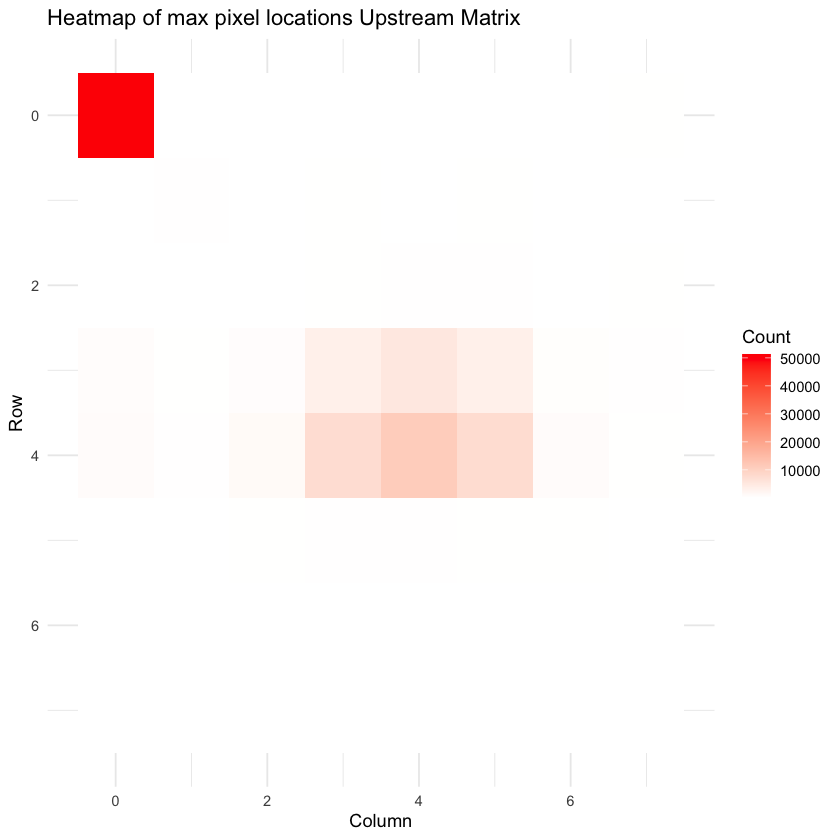

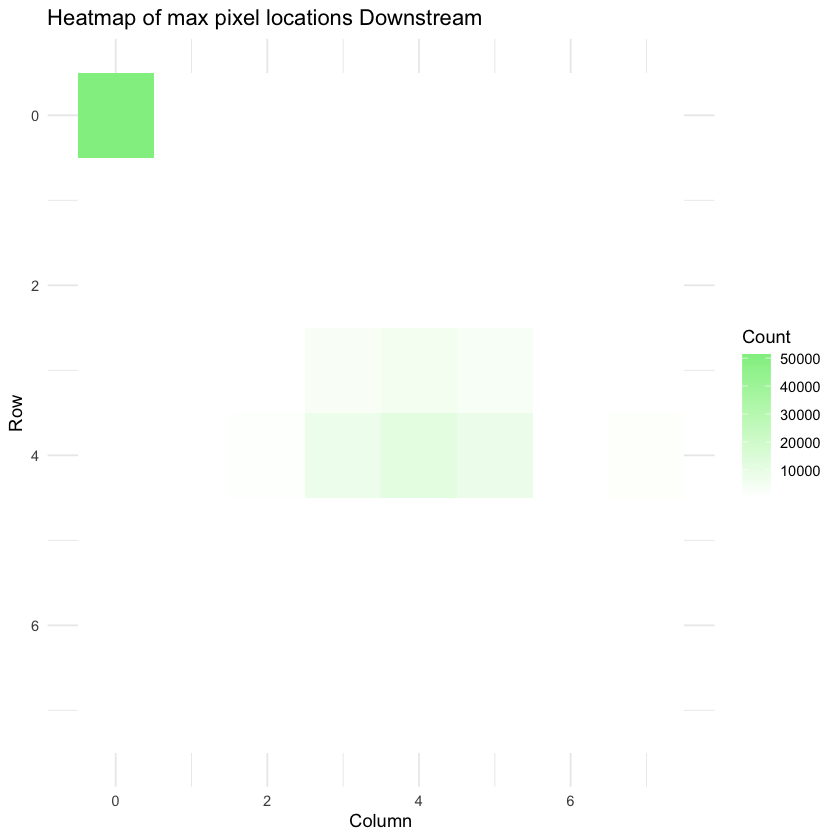

In [120]:
# Heatmap of the maximum pixel value for the first palate
ggplot(max_index_1, aes(x = col, y = row, fill = n)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "red") +
  scale_y_reverse() +  
  theme_minimal() +
  labs(title = "Heatmap of max pixel locations Upstream Matrix",
       x = "Column", y = "Row", fill = "Count")

# Heatmap of the maximum pixel value for the 2nd palate
ggplot(max_index_2, aes(x = col, y = row, fill = n)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "lightgreen") +
  scale_y_reverse() +  
  theme_minimal() +
  labs(title = "Heatmap of max pixel locations Downstream",
       x = "Column", y = "Row", fill = "Count")

For the second maximum:

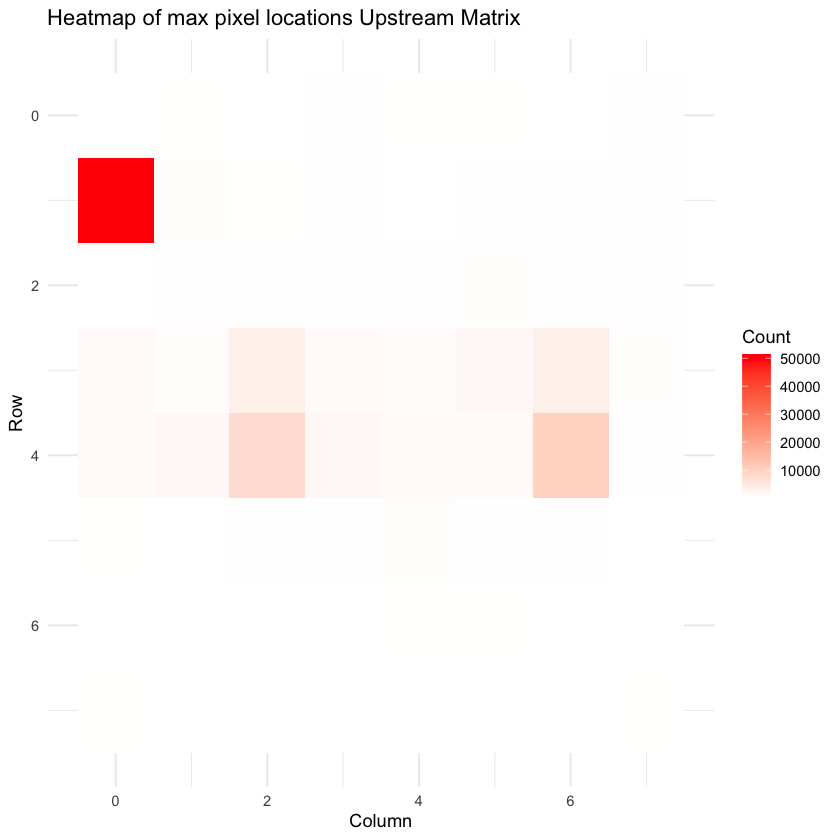

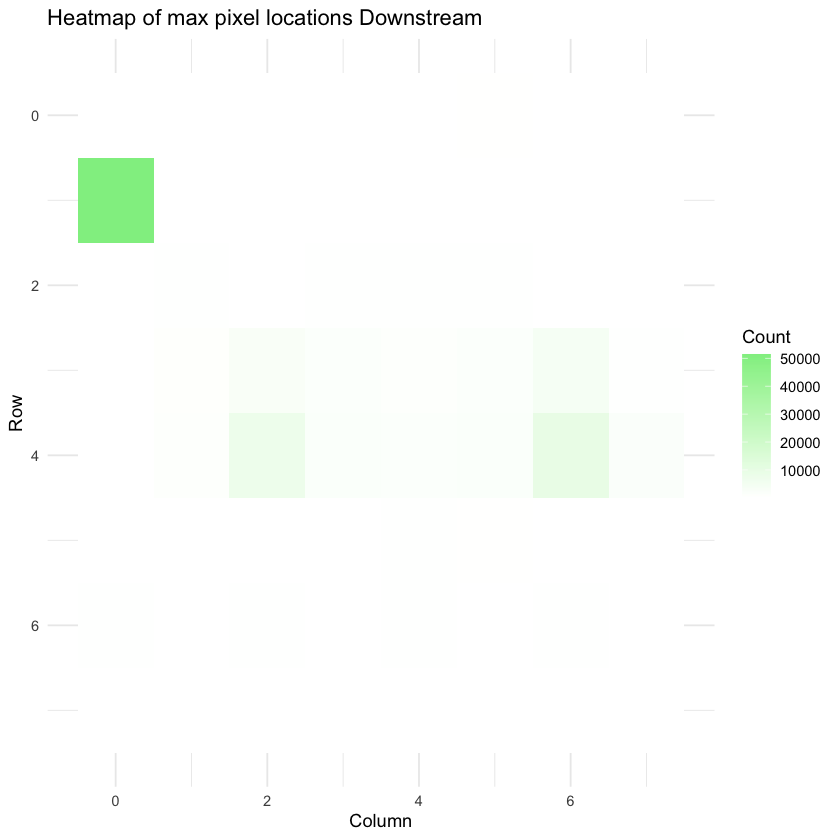

In [121]:
# Heatmap of the maximum pixel value for the first palate
ggplot(snd_max_index_1, aes(x = col, y = row, fill = n)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "red") +
  scale_y_reverse() +  
  theme_minimal() +
  labs(title = "Heatmap of max pixel locations Upstream Matrix",
       x = "Column", y = "Row", fill = "Count")

# Heatmap of the maximum pixel value for the 2nd palate
ggplot(snd_max_index_2, aes(x = col, y = row, fill = n)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "lightgreen") +
  scale_y_reverse() +  
  theme_minimal() +
  labs(title = "Heatmap of max pixel locations Downstream",
       x = "Column", y = "Row", fill = "Count")

### Count the number of times the pixel index of the maximum signal in the upstream matrix matches that of the downstream matrix. Create a bar plot, considering only events where the maximum value exceeds 10.

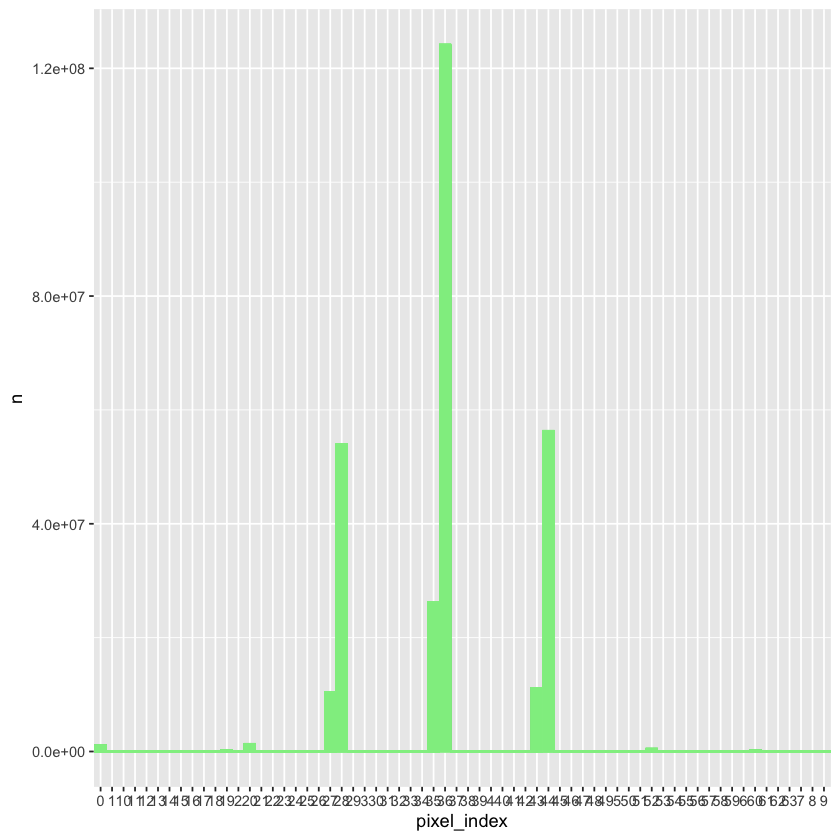

In [122]:
grp_matche <- max_df_1 %>%
    filter(max > 10) %>%
    count(pixel_index) %>%
    left_join(max_df_2, by = "pixel_index")
    
ggplot(grp_matche, aes(x=pixel_index, y = n)) +
    geom_bar(stat = "Identity", color = "lightgreen")

### Identify the four most frequently occurring pairs of maximum pixel indices (Max Index Upstream, Max Index Downstream)

In [123]:
grp_matche <- max_df_1 %>%
    count(pixel_index) %>%
    left_join(max_df_2, by = "pixel_index") 

grp_matche_4 <- grp_matche %>%
    group_by(pixel_index) %>%
    count() %>%
    arrange(desc(n))


grp_matche_4



pixel_index,n
<chr>,<int>
0,51372
36,11548
44,7860
28,7465
35,5075
43,3363
27,3194
60,1265
20,1126
